In [ ]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent.parent if '__file__' in globals() else Path.cwd().parent.parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, create_label_to_class_map, extract_features_for_ml, FeatureConfig

# Initialize dataset manager
dataset_path = project_root / "data_set_4"
data_loader = DataLoader(dataset_path)

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42, 
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])

feat_conf = FeatureConfig(
    sensor_type="vibration",
    selected_channels=["ch1", "ch2"]
)

load_params = {
    "classes": None,
    "loads": None,
    "frequencies": None,
    "sensor_types": "vibration",
    "sample_ids": None,
}
window_params = {
    "window_size": 10000,
    "overlap_ratio": 0.5,
    "max_windows_per_class": 4975,
    "shuffle": False,
    "random_state": 42,
}

data, metadata = data_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
)

windows, labels, win_metadata = create_windows_for_ml(
        data_list=data,
        metadata_list=metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

features, feature_names = extract_features_for_ml(
        windows,
        metadata_list=win_metadata,
        sensor_type=feat_conf.sensor_type,
        feature_config=feat_conf
)


INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available windows


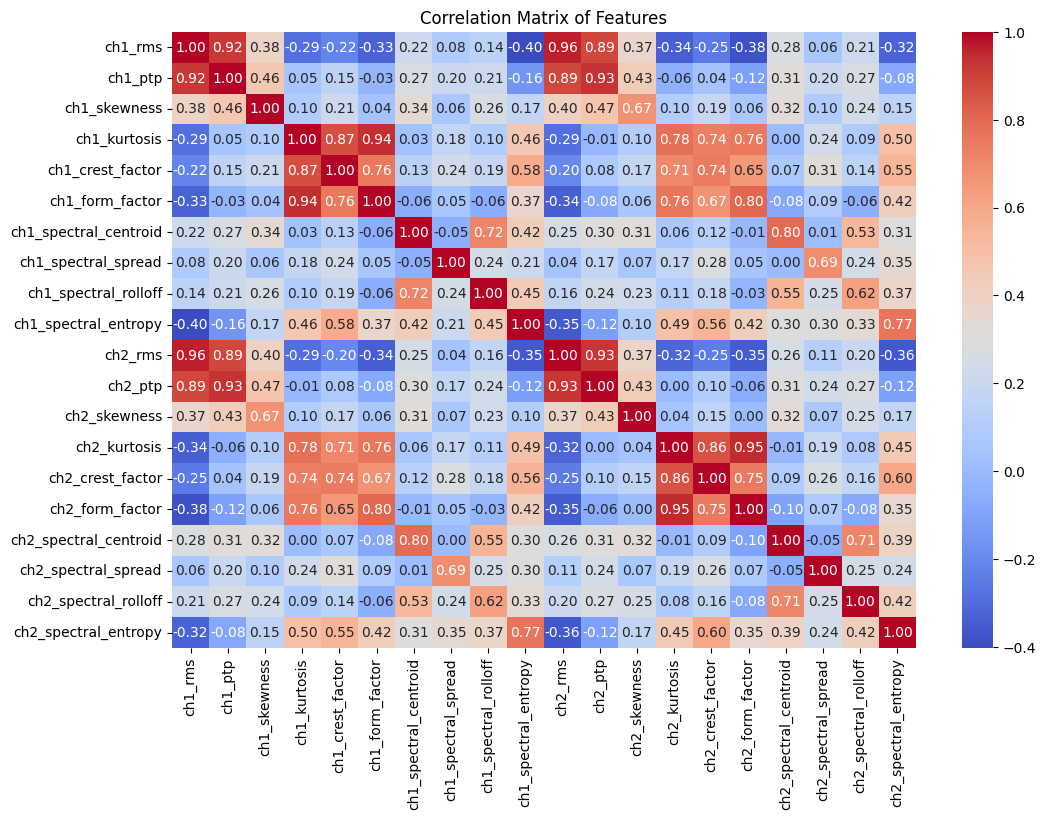

In [11]:
# Correlation Matrix of Features
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert features to a DataFrame
features_df = pd.DataFrame(features, columns=feature_names)

# Calculate the correlation matrix
correlation_matrix = features_df.corr()

# Display the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Features")
plt.show()


In [8]:

test_path = project_root / "data_set_4"
test_loader = DataLoader(test_path)

test_feat_conf = FeatureConfig(
    sensor_type="vibration",
    selected_channels=["ch3", "ch4"]
    )

test_data, test_metadata = test_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
)

test_windows, test_labels, test_win_metadata = create_windows_for_ml(
        data_list=test_data,
        metadata_list=test_metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
)

test_features, test_feature_names = extract_features_for_ml(
        test_windows,
        metadata_list=test_win_metadata,
        sensor_type=test_feat_conf.sensor_type,
        feature_config=test_feat_conf,
        include_categorical=False, # just try to remove categorial
)


INFO:ml_toolbox.data_loader.data_loader:Loading 64 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 64 files
INFO:ml_toolbox.data_loader.windowing:Class 'd0': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd3': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd6': selected 4975 of 4976 available windows
INFO:ml_toolbox.data_loader.windowing:Class 'd9': selected 4975 of 4976 available windows


In [9]:

pipeline.fit(features, labels)
preds = pipeline.predict(test_features)
score = pipeline.score(test_features, test_labels)
print(f"Test Accuracy: {score:.4f}")

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, preds, labels=pipeline.classes_)
print("Confusion Matrix:")
print(cm)

Test Accuracy: 0.9527
Confusion Matrix:
[[4532  422   21    0]
 [ 294 4634   47    0]
 [   2  145 4828    0]
 [   0    0   11 4964]]
